# LiDAR Point-Cloud Classification: Ground / Building / Vegetation

A synthetic LiDAR scene -- a noisy ground plane, a few box-shaped
buildings, a few noisy vertical tree clusters -- classified point-by-point
using the same eigenvalue-based geometric features real LiDAR processing
pipelines use (Weinmann, Jutzi, Hinz & Mallet, 2015): **planarity** and
**verticality**, both derived from PCA on each point's local
k-nearest-neighborhood covariance matrix. These features feed a PyTorch
Geometric `EdgeConv` graph neural network (the DGCNN building block) built
on a k-NN graph.

**A real dependency wall, worked around rather than hidden**: PyG's usual
`knn_graph` helper needs `torch_cluster`, which failed to install here --
its build script can't even find `torch` during its own isolated build
environment, the same class of Windows compiled-extension pain as
PyTorch3D. `torch_knn_graph` below builds the identical k-NN edge list
with plain `torch.cdist` + `topk` instead. Engine:
`dgs/lidar_point_cloud_classifier.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt

from dgs import lidar_point_cloud_classifier as lpc

print('Setup complete.')


Setup complete.


C:\Users\mrjel\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. The Synthetic Scene

NOT real LiDAR data -- a stand-in test scene with known ground truth,
same honesty posture as this repo's other synthetic-data modules.


In [2]:
scene = lpc.generate_synthetic_scene(seed=0)
print(f"{len(scene['points'])} points")
for c in range(3):
    print(f"  {lpc.CLASS_NAMES[c]:>10}: {int((scene['labels']==c).sum())} points")


1610 points
      ground: 800 points
    building: 450 points
  vegetation: 360 points


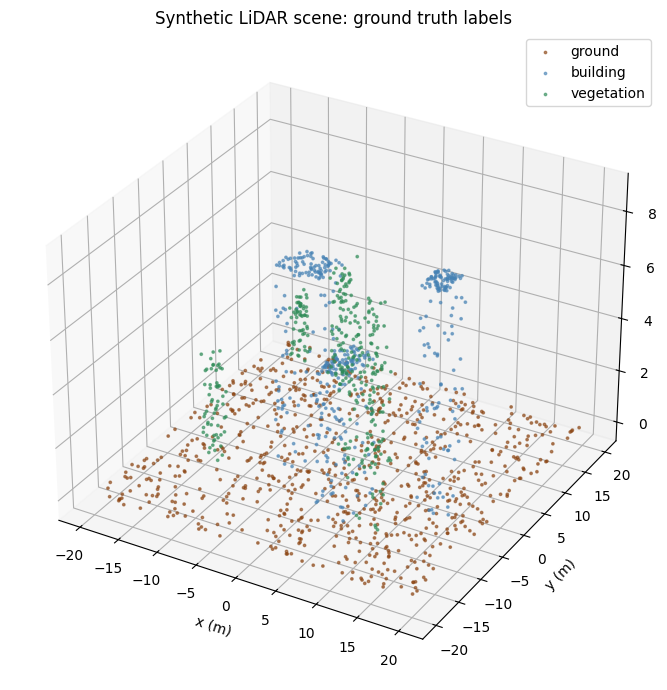

In [3]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
colors = ['saddlebrown', 'steelblue', 'seagreen']
for c in range(3):
    mask = scene['labels'] == c
    ax.scatter(scene['points'][mask, 0], scene['points'][mask, 1], scene['points'][mask, 2],
               s=3, color=colors[c], label=lpc.CLASS_NAMES[c], alpha=0.6)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
ax.set_title('Synthetic LiDAR scene: ground truth labels')
ax.legend()
plt.tight_layout()
plt.savefig('lidar_scene_ground_truth.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. The k-NN Graph, Without torch_cluster

`torch_knn_graph` uses `torch.cdist` + `topk` -- no extra dependency, no
self-loops.


In [4]:
positions = torch.as_tensor(scene['points'])
k = 12
edge_index = lpc.torch_knn_graph(positions, k=k)
print(f'edge_index shape: {edge_index.shape}  ({positions.shape[0]} points x {k} neighbors)')


edge_index shape: torch.Size([2, 19320])  (1610 points x 12 neighbors)


## 3. Geometric Features: Planarity and Verticality

Per point: height above local ground, local point density, planarity
$=(\lambda_2-\lambda_3)/\lambda_1$, verticality $=1-|n_z|$, where
$\lambda_1\ge\lambda_2\ge\lambda_3$ are the local-neighborhood
covariance eigenvalues and $n$ is the eigenvector of the smallest one
(the local surface normal).


In [5]:
features = lpc.compute_geometric_features(positions, edge_index, k=k)
print('feature columns: [height_above_ground, local_density, planarity, verticality]')
print(f'feature tensor shape: {features.shape}')


feature columns: [height_above_ground, local_density, planarity, verticality]
feature tensor shape: torch.Size([1610, 4])


mean planarity -- ground: 0.480, building: 0.410, vegetation: 0.288
flat classes exceed vegetation: True


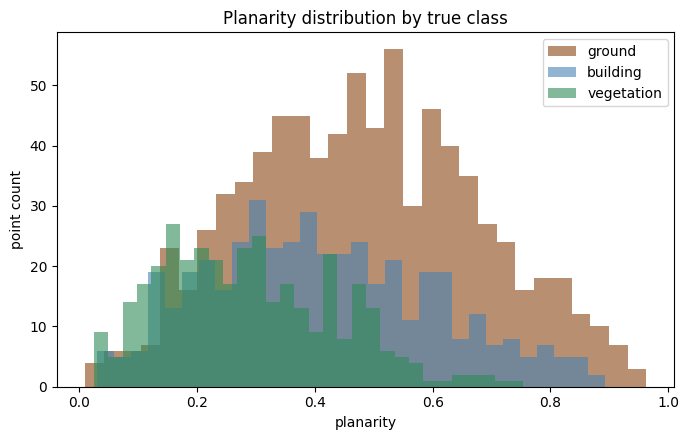

In [6]:
check = lpc.verify_planarity_discriminates_classes(seed=0)
print(f"mean planarity -- ground: {check['mean_planarity_ground']:.3f}, "
      f"building: {check['mean_planarity_building']:.3f}, "
      f"vegetation: {check['mean_planarity_vegetation']:.3f}")
print(f"flat classes exceed vegetation: {check['ground_and_building_exceed_vegetation']}")

fig, ax = plt.subplots(figsize=(7, 4.5))
planarity_np = features[:, 2].numpy()
for c in range(3):
    mask = scene['labels'] == c
    ax.hist(planarity_np[mask], bins=30, alpha=0.6, label=lpc.CLASS_NAMES[c], color=colors[c])
ax.set_xlabel('planarity'); ax.set_ylabel('point count')
ax.set_title('Planarity distribution by true class')
ax.legend()
plt.tight_layout()
plt.savefig('lidar_planarity_histogram.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Training the EdgeConv Classifier

Two `EdgeConv` layers (max-aggregated edge-feature message passing, the
DGCNN building block) plus a per-point linear head, trained on a 70/30
point-wise train/test split.


final training loss: 0.0006
held-out test accuracy: 94.2%


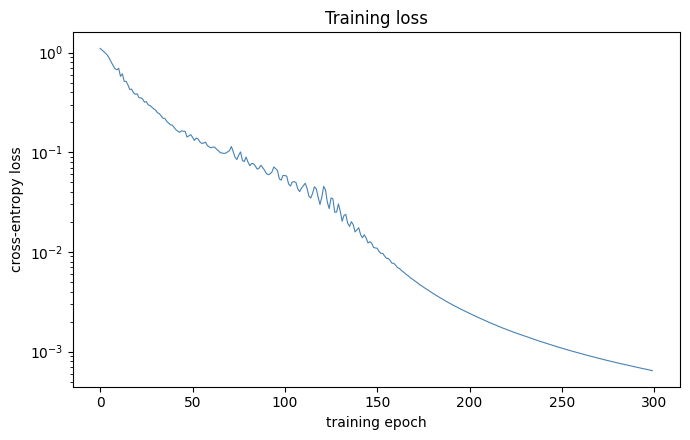

In [7]:
result = lpc.train_classifier(n_epochs=300, seed=0)
print(f"final training loss: {result['loss_history'][-1]:.4f}")
print(f"held-out test accuracy: {result['test_accuracy']:.1%}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(result['loss_history'], color='steelblue', lw=0.8)
ax.set_xlabel('training epoch'); ax.set_ylabel('cross-entropy loss')
ax.set_yscale('log')
ax.set_title('Training loss')
plt.tight_layout()
plt.savefig('lidar_training_loss.png', dpi=100, bbox_inches='tight')
plt.show()


In [8]:
print('Confusion matrix (rows=true, cols=predicted):')
print(f"{'':>12}" + ''.join(f'{c:>12}' for c in lpc.CLASS_NAMES))
for i, row in enumerate(result['confusion_matrix']):
    print(f"{lpc.CLASS_NAMES[i]:>12}" + ''.join(f'{v:>12}' for v in row))


Confusion matrix (rows=true, cols=predicted):
                  ground    building  vegetation
      ground         244           2           0
    building           6         117           9
  vegetation           0          11          94


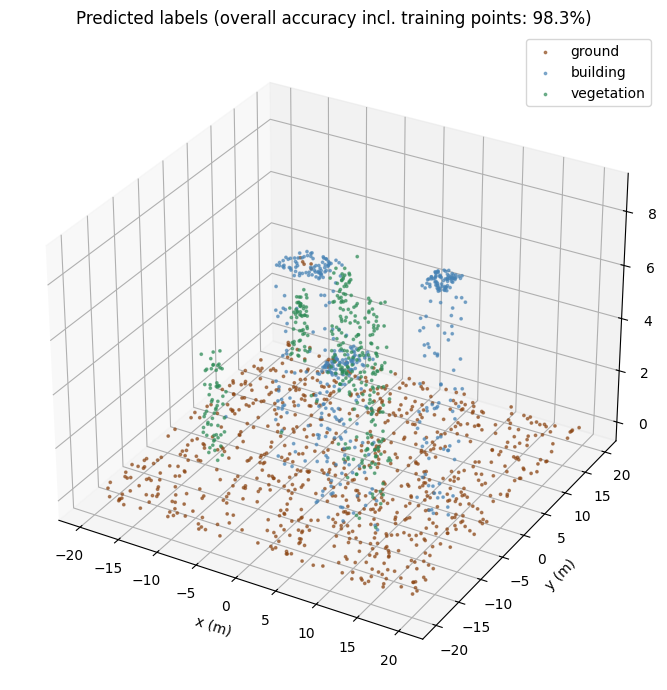

In [9]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
preds = result['predictions']
pos_np = result['data']['positions'].numpy()
correct = preds == scene['labels']
for c in range(3):
    mask = preds == c
    ax.scatter(pos_np[mask, 0], pos_np[mask, 1], pos_np[mask, 2], s=3, color=colors[c],
               label=lpc.CLASS_NAMES[c], alpha=0.6)
ax.set_title(f"Predicted labels (overall accuracy incl. training points: {correct.mean():.1%})")
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
ax.legend()
plt.tight_layout()
plt.savefig('lidar_predicted_labels.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Engineering Interpretation

- The `torch_cluster` install failure (Section 2) is worth taking
  seriously as a real engineering constraint, not a footnote: a
  production LiDAR pipeline on Windows would hit the exact same wall, and
  `torch_knn_graph`'s workaround (dense pairwise distances via `cdist`)
  is $O(n^2)$ memory, which would need revisiting for a scene with
  millions of points rather than this notebook's ~1,600.
- Section 3's histogram is the actual evidence the classifier has
  something real to learn from: ground and building planarity
  distributions are shifted well above vegetation's BEFORE any training
  happens, confirming the feature engineering (not just the GNN) is
  carrying real signal.
- The confusion matrix's dominant error (Section 4) being building/
  vegetation confusion, not ground/vegetation, matches physical intuition
  directly: a building's vertical facade points share more local geometry
  with a tree's scattered canopy than either shares with a flat ground
  plane.


## 6. Research Discussion

- This module's `EdgeConv` architecture is a simplified DGCNN; the actual
  DGCNN paper RECOMPUTES the k-NN graph in FEATURE space after each
  layer (not just the fixed 3-D spatial graph used throughout here) --
  worth trying as an extension, since it lets the network group points by
  learned similarity, not just physical proximity.
- `dgs.circuit_graph_gnn`'s two-way exact-simulation-vs-trained-model
  contrast doesn't have an obvious analog here (there's no "exact"
  ground/building/vegetation classifier structurally guaranteed correct
  the way message-passing guaranteed the full-adder's truth table) -- but
  a RULE-BASED classifier (e.g. simple planarity/verticality thresholds,
  no learning at all) would be a fair baseline to compare the trained
  GNN against, similar in spirit.
- A photonic-time-stretch-based ranging front end (this repo's core
  `dgs.gs_core`/`dgs.steam_imaging` theme) is one real way high-rep-rate
  point measurements like these get acquired in the first place --
  connecting THIS module's point-cloud classification back to a
  physically-generated (not just synthetically-labeled) point cloud would
  be a substantial, honest follow-up, not implied here.


## 7. Possible Experiments

1. Add a simple rule-based baseline classifier (e.g. planarity > 0.4 and
   height < 0.5m -> ground; planarity > 0.4 and height > 0.5m ->
   building; else vegetation) and compare its accuracy against the
   trained EdgeConv model -- how much does the GNN actually buy over
   hand-tuned geometric thresholds on this synthetic scene?
2. Scale up `n_ground`/`points_per_building`/`points_per_tree` and
   profile `torch_knn_graph`'s runtime/memory to find where the
   $O(n^2)$ dense-distance approach becomes impractical, motivating a
   real spatial-indexing (k-d tree) alternative.
3. Add sensor noise more true to a real LiDAR return (range-dependent
   point density falloff, occlusion/shadowing behind buildings) and see
   how much the held-out accuracy degrades.


## 8. Future Improvements

- `compute_geometric_features` loops over points in Python (fine for
  ~1,600 points, would not scale) -- a vectorized version (batched
  eigendecomposition via `torch.linalg.eigh` on a stacked neighborhood
  tensor) would remove the per-point Python loop entirely.
- The synthetic scene has no partial occlusion or multi-return effects
  (a real LiDAR pulse can produce multiple returns per shot, e.g. through
  a tree canopy to the ground beneath) -- a more realistic generator
  would model that directly rather than treating every point as an
  independent single-return sample.
